### Install Packages

In [ ]:
# Install required packages
!pip install -q tensorflow scikit-learn seaborn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
train_path = '/content/drive/MyDrive/deshapriyaaiya/train.csv'
test_path = '/content/drive/MyDrive/deshapriyaaiya/test.csv'

# Load data
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nColumns in training data:")
print(train_df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training data shape: (1935, 6)
Test data shape: (154, 6)

Columns in training data:
['Date', 'Maximum Temperature degrees (F)', 'Minimum Temperature degrees (F)', 'Precipitation (inches)', 'Snow (inches)', 'Snow Depth (inches)']


*italicized text* Initial Data Exploration Visualization



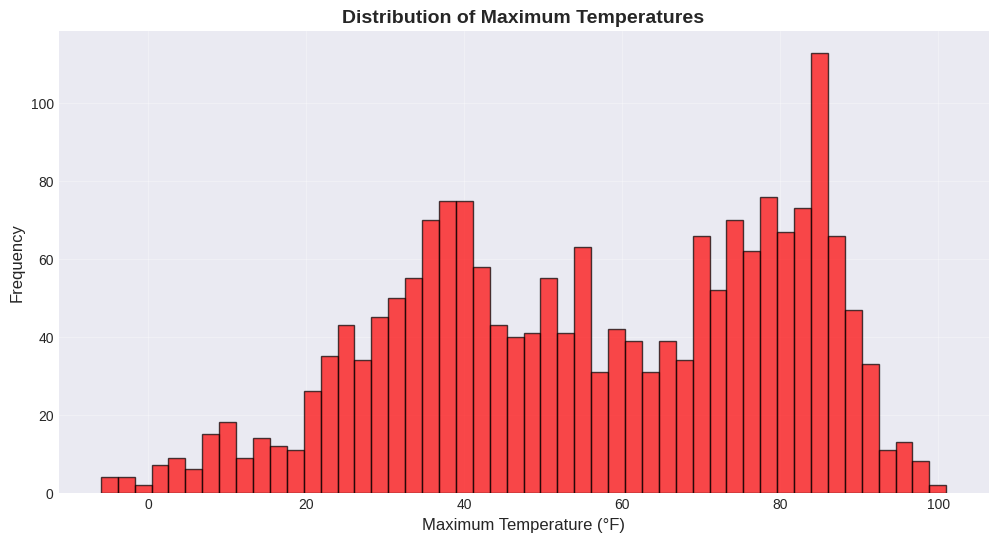

In [ ]:
# Figure 1: Maximum Temperature Distribution
plt.figure(figsize=(12, 6))
plt.hist(train_df['Maximum Temperature degrees (F)'], bins=50, edgecolor='black', alpha=0.7, color='red')
plt.xlabel('Maximum Temperature (°F)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Maximum Temperatures', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('max_temp_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

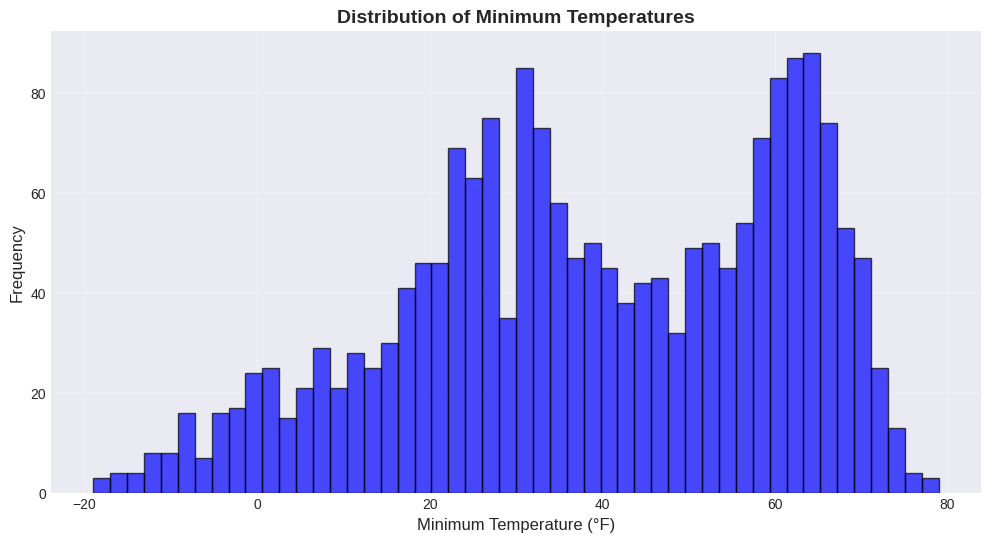

In [ ]:
# Figure 2: Minimum Temperature Distribution
plt.figure(figsize=(12, 6))
plt.hist(train_df['Minimum Temperature degrees (F)'], bins=50, edgecolor='black', alpha=0.7, color='blue')
plt.xlabel('Minimum Temperature (°F)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Minimum Temperatures', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('min_temp_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

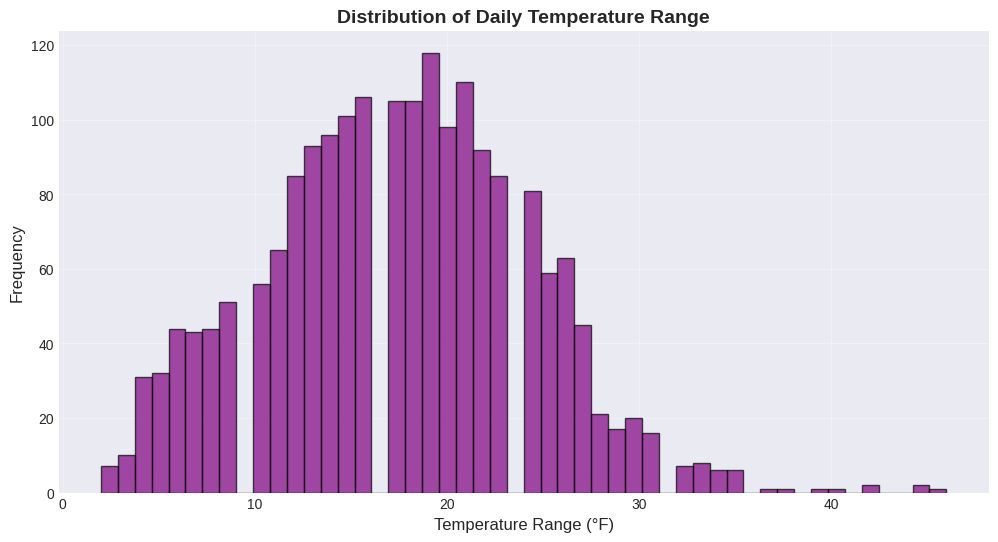

In [ ]:
# Figure 3: Temperature Range Distribution
train_df['temp_range'] = train_df['Maximum Temperature degrees (F)'] - train_df['Minimum Temperature degrees (F)']
plt.figure(figsize=(12, 6))
plt.hist(train_df['temp_range'], bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Temperature Range (°F)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Daily Temperature Range', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('temp_range_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

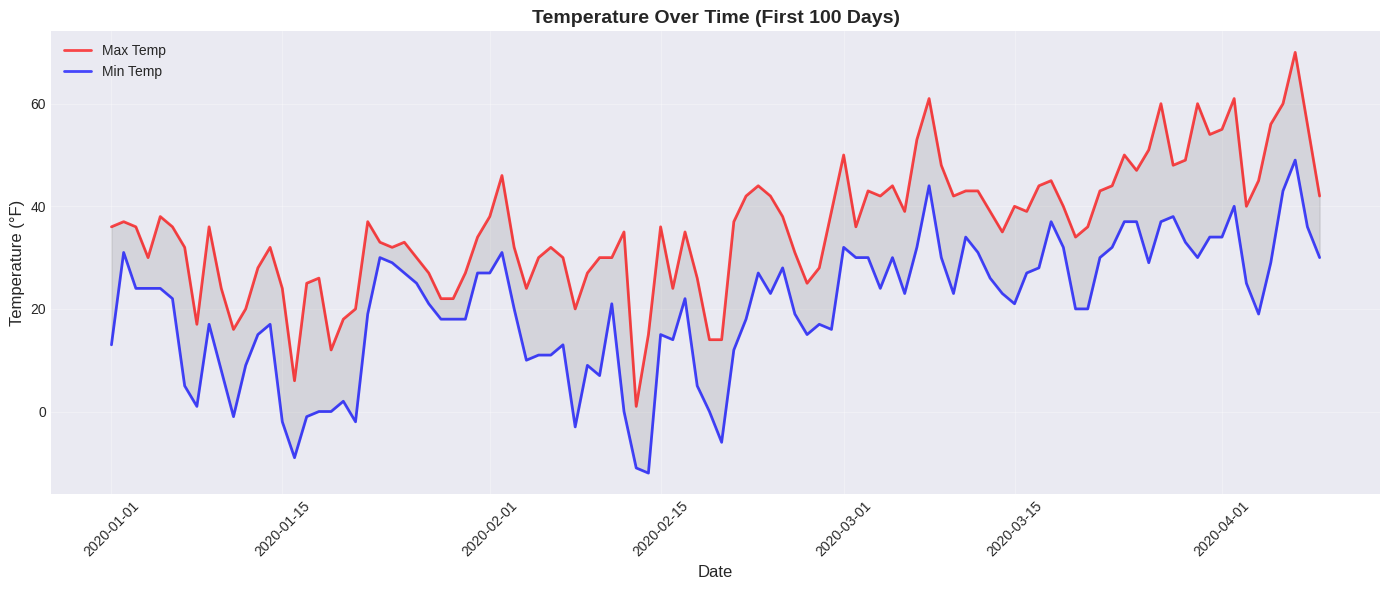

In [ ]:
# Convert date
train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

# Figure 4: Temperature over time (first 100 days)
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'].iloc[:100], train_df['Maximum Temperature degrees (F)'].iloc[:100],
         label='Max Temp', linewidth=2, color='red', alpha=0.7)
plt.plot(train_df['Date'].iloc[:100], train_df['Minimum Temperature degrees (F)'].iloc[:100],
         label='Min Temp', linewidth=2, color='blue', alpha=0.7)
plt.fill_between(train_df['Date'].iloc[:100],
                 train_df['Minimum Temperature degrees (F)'].iloc[:100],
                 train_df['Maximum Temperature degrees (F)'].iloc[:100],
                 alpha=0.2, color='gray')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°F)', fontsize=12)
plt.title('Temperature Over Time (First 100 Days)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('temperature_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

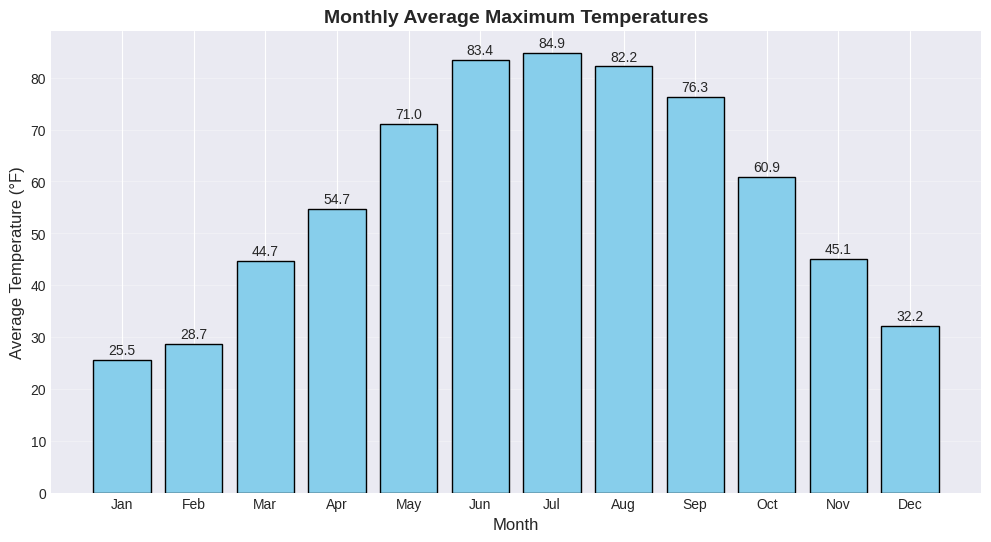

In [ ]:
# Figure 5: Monthly average temperature
train_df['month'] = train_df['Date'].dt.month
monthly_avg = train_df.groupby('month')['Maximum Temperature degrees (F)'].mean()

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_avg.index, monthly_avg.values, color='skyblue', edgecolor='black')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Temperature (°F)', fontsize=12)
plt.title('Monthly Average Maximum Temperatures', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.savefig('monthly_avg_temp.png', dpi=300, bbox_inches='tight')
plt.show()

# **HeatMap**

FEATURE CORRELATION ANALYSIS
Checking data types:
Maximum Temperature degrees (F): float64
Minimum Temperature degrees (F): float64
Precipitation (inches)        : float64
Snow (inches)                 : float64
Snow Depth (inches)           : float64
temp_range                    : float64

Missing values after cleaning:

Correlation matrix shape: (6, 6)


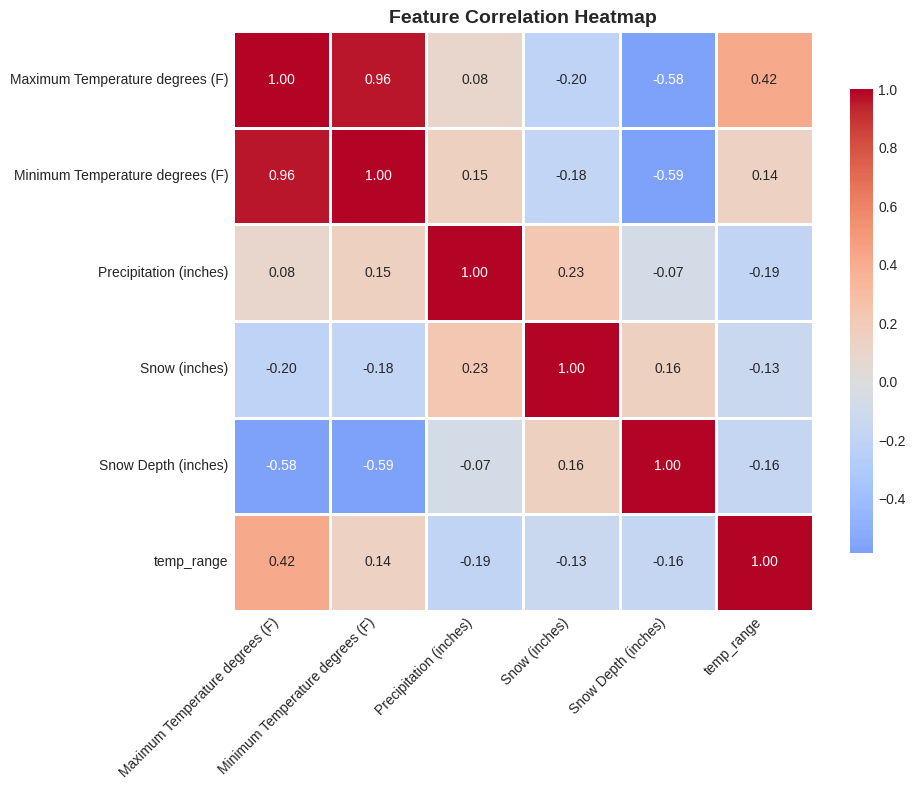


Correlation with Maximum Temperature:
---------------------------------------------
Minimum Temperature degrees (F):  0.959 (Very Strong) (positive)
Precipitation (inches)        :  0.085 (Very Weak) (positive)
Snow (inches)                 : -0.204 (Weak) (negative)
Snow Depth (inches)           : -0.584 (Strong) (negative)
temp_range                    :  0.417 (Moderate) (positive)


In [ ]:
print("="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

# First handle the 'T' values
def clean_numeric_data(df):
    """Clean numeric data by handling 'T' values"""
    df_clean = df.copy()

    # Handle 'T' values in specific columns
    for col in ['Precipitation (inches)', 'Snow (inches)', 'Snow Depth (inches)']:
        if col in df_clean.columns:
            # Replace 'T' with 0.001 (trace amount)
            df_clean[col] = df_clean[col].replace('T', 0.001)
            # Convert to numeric, coercing errors
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    return df_clean

# Clean the data
train_df_clean = clean_numeric_data(train_df)

# Select numeric columns for correlation
numeric_columns = ['Maximum Temperature degrees (F)',
                   'Minimum Temperature degrees (F)',
                   'Precipitation (inches)',
                   'Snow (inches)',
                   'Snow Depth (inches)']

# Calculate temp_range after cleaning
train_df_clean['temp_range'] = train_df_clean['Maximum Temperature degrees (F)'] - train_df_clean['Minimum Temperature degrees (F)']
numeric_columns.append('temp_range')

print("Checking data types:")
for col in numeric_columns:
    print(f"{col:30s}: {train_df_clean[col].dtype}")

print(f"\nMissing values after cleaning:")
for col in numeric_columns:
    missing = train_df_clean[col].isnull().sum()
    if missing > 0:
        print(f"{col:30s}: {missing} missing values")

# Fill any remaining NaN values with 0
for col in numeric_columns:
    train_df_clean[col] = train_df_clean[col].fillna(0)


correlation_matrix = train_df_clean[numeric_columns].corr()

print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")

# Figure: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8},
            linewidths=1,
            linecolor='white',
            annot_kws={'size': 10})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print correlation with target
print("\nCorrelation with Maximum Temperature:")
print("-" * 45)
for col in correlation_matrix.columns:
    if col != 'Maximum Temperature degrees (F)':
        corr_value = correlation_matrix.loc['Maximum Temperature degrees (F)', col]

        # Interpret correlation strength
        strength = ""
        if abs(corr_value) >= 0.7:
            strength = " (Very Strong)"
        elif abs(corr_value) >= 0.5:
            strength = " (Strong)"
        elif abs(corr_value) >= 0.3:
            strength = " (Moderate)"
        elif abs(corr_value) >= 0.1:
            strength = " (Weak)"
        else:
            strength = " (Very Weak)"

        direction = "positive" if corr_value > 0 else "negative"
        print(f"{col:30s}: {corr_value:6.3f}{strength} ({direction})")




Creating pairplot for top correlated features...


<Figure size 1200x1000 with 0 Axes>

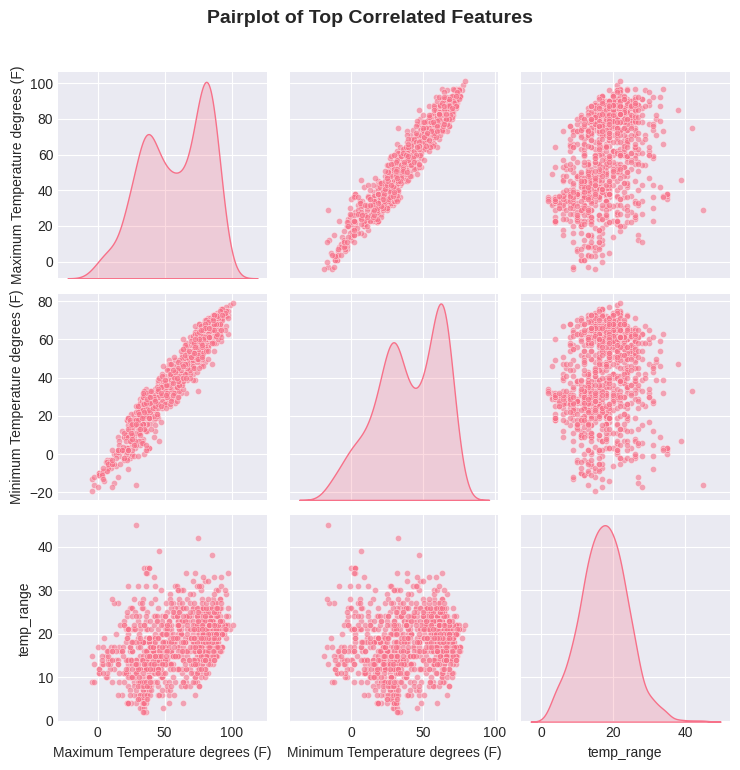

In [ ]:
# Additional visualization: Pairplot for top correlated features
print("\nCreating pairplot for top correlated features...")
top_features = ['Maximum Temperature degrees (F)',
                'Minimum Temperature degrees (F)',
                'temp_range']

plt.figure(figsize=(12, 10))
sns.pairplot(train_df_clean[top_features].head(1000),
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Pairplot of Top Correlated Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pairplot_correlated_features.png', dpi=300, bbox_inches='tight')
plt.show()

SCATTER PLOT ANALYSIS


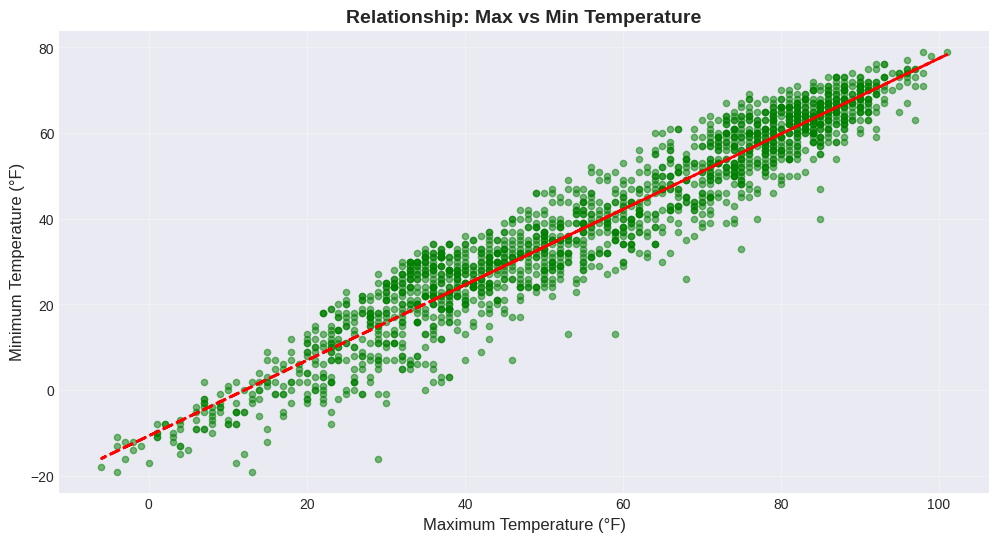

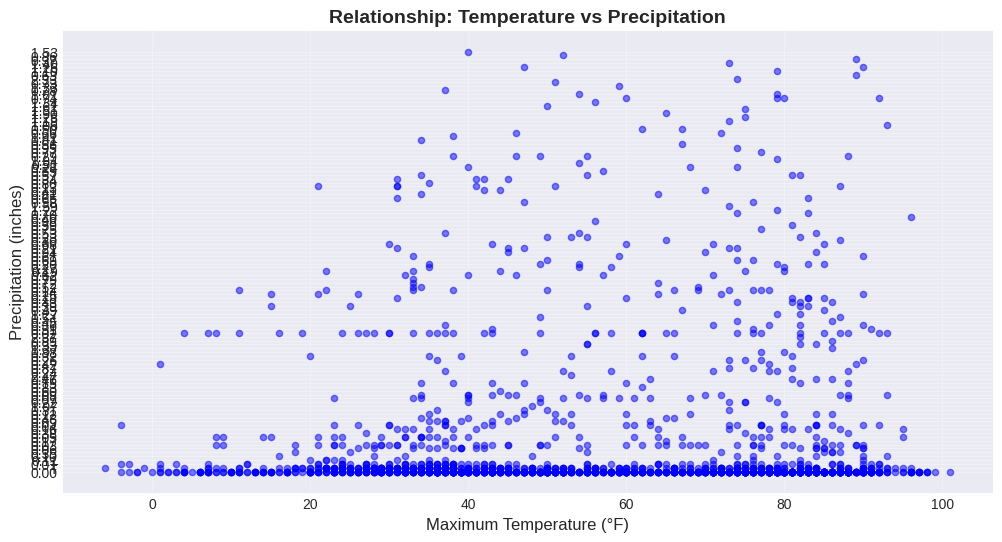

In [ ]:
print("="*60)
print("SCATTER PLOT ANALYSIS")
print("="*60)

# Figure 7: Max vs Min Temperature Scatter
plt.figure(figsize=(12, 6))
plt.scatter(train_df['Maximum Temperature degrees (F)'],
           train_df['Minimum Temperature degrees (F)'],
           alpha=0.5, s=20, c='green')
plt.xlabel('Maximum Temperature (°F)', fontsize=12)
plt.ylabel('Minimum Temperature (°F)', fontsize=12)
plt.title('Relationship: Max vs Min Temperature', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)


z = np.polyfit(train_df['Maximum Temperature degrees (F)'],
               train_df['Minimum Temperature degrees (F)'], 1)
p = np.poly1d(z)
plt.plot(train_df['Maximum Temperature degrees (F)'],
         p(train_df['Maximum Temperature degrees (F)']),
         "r--", linewidth=2)

plt.savefig('max_min_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 8: Temperature vs Precipitation
plt.figure(figsize=(12, 6))
plt.scatter(train_df['Maximum Temperature degrees (F)'],
           train_df['Precipitation (inches)'],
           alpha=0.5, s=20, c='blue')
plt.xlabel('Maximum Temperature (°F)', fontsize=12)
plt.ylabel('Precipitation (inches)', fontsize=12)
plt.title('Relationship: Temperature vs Precipitation', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('temp_precip_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Box Plots for Seasonal Analysis

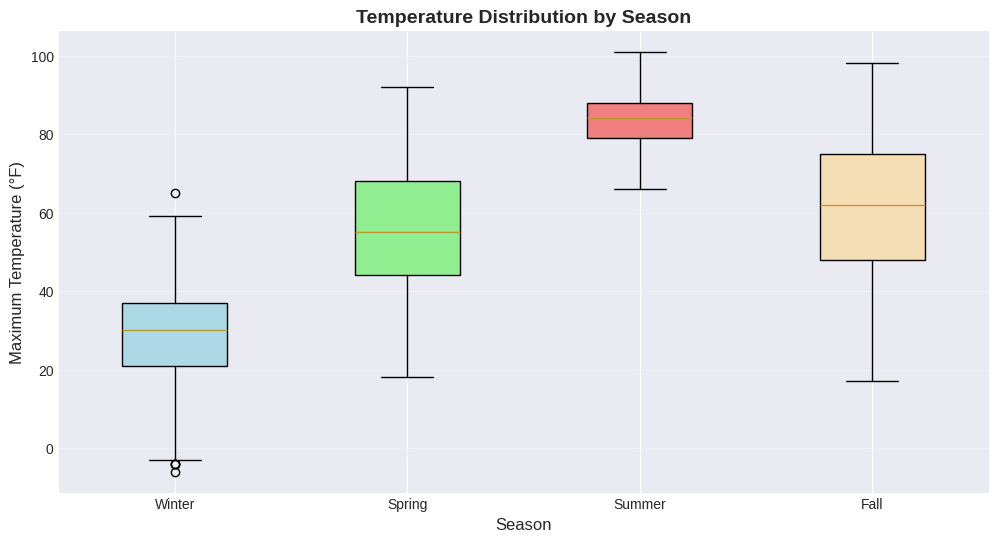

In [ ]:
# Create seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

train_df['season'] = train_df['month'].apply(get_season)

# Figure 9: Box plot by season
plt.figure(figsize=(12, 6))
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
box_data = [train_df[train_df['season'] == season]['Maximum Temperature degrees (F)'].values
            for season in season_order]

bp = plt.boxplot(box_data, labels=season_order, patch_artist=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'wheat']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Maximum Temperature (°F)', fontsize=12)
plt.title('Temperature Distribution by Season', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.savefig('seasonal_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


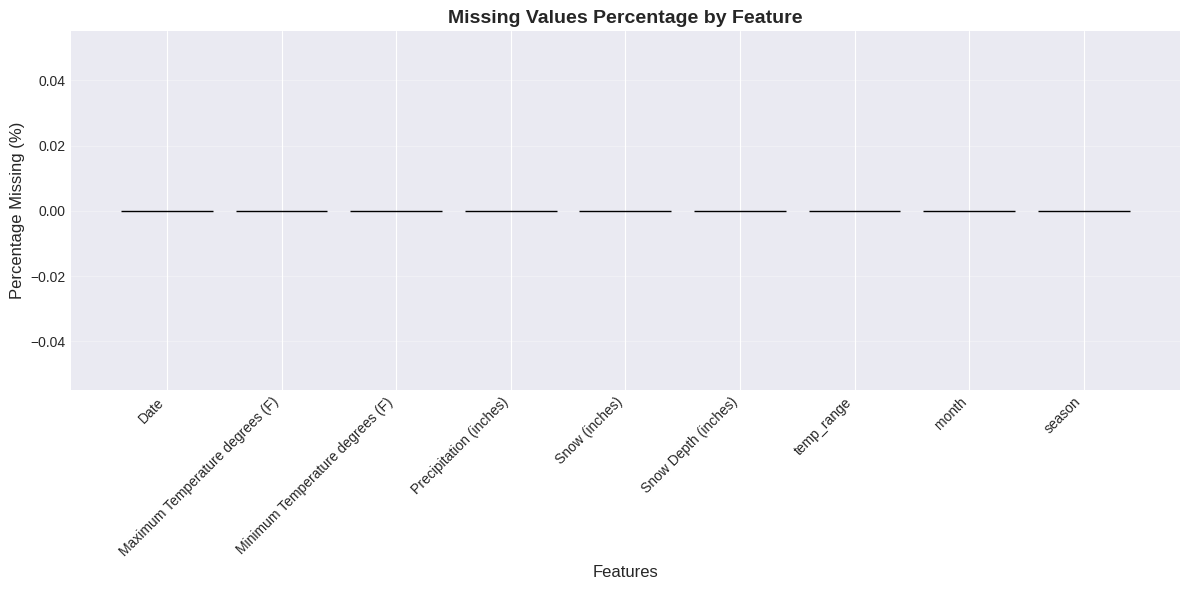


Summary Statistics for Maximum Temperature:
count    1935.000000
mean       56.422739
std        23.847696
min        -6.000000
25%        37.000000
50%        57.000000
75%        78.000000
max       101.000000
Name: Maximum Temperature degrees (F), dtype: float64

Missing Values Summary:


In [ ]:


# Figure 11: Missing values visualization
missing_values = train_df.isnull().sum()
missing_percentage = (missing_values / len(train_df)) * 100

plt.figure(figsize=(12, 6))
bars = plt.bar(missing_values.index, missing_percentage.values,
               color='salmon', edgecolor='black')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Percentage Missing (%)', fontsize=12)
plt.title('Missing Values Percentage by Feature', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSummary Statistics for Maximum Temperature:")
print(train_df['Maximum Temperature degrees (F)'].describe())

print("\nMissing Values Summary:")
for col in train_df.columns:
    missing_count = train_df[col].isnull().sum()
    if missing_count > 0:
        print(f"{col:30s}: {missing_count:5d} missing ({missing_count/len(train_df)*100:.2f}%)")

In [ ]:


def clean_preprocess_data(df):
    """Clean preprocessing function"""
    df_clean = df.copy()

    # 1. Handle 'T' values in precipitation/snow columns
    for col in ['Precipitation (inches)', 'Snow (inches)', 'Snow Depth (inches)']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].replace('T', 0.0)
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # 2. Extract temporal features
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    df_clean['month'] = df_clean['Date'].dt.month
    df_clean['day_of_year'] = df_clean['Date'].dt.dayofyear

    # 3. Cyclical encoding for seasonality
    df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
    df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

    # 4. Temperature features
    df_clean['temp_range'] = df_clean['Maximum Temperature degrees (F)'] - df_clean['Minimum Temperature degrees (F)']

    # 5. Fill missing values
    df_clean = df_clean.fillna(0)

    return df_clean

# Apply preprocessing
train_processed = clean_preprocess_data(train_df)
test_processed = clean_preprocess_data(test_df)

print(f"Processed training data shape: {train_processed.shape}")
print(f"Processed test data shape: {test_processed.shape}")

Processed training data shape: (1935, 12)
Processed test data shape: (154, 11)


 Feature Engineering Visualization

FEATURE ENGINEERING VISUALIZATION


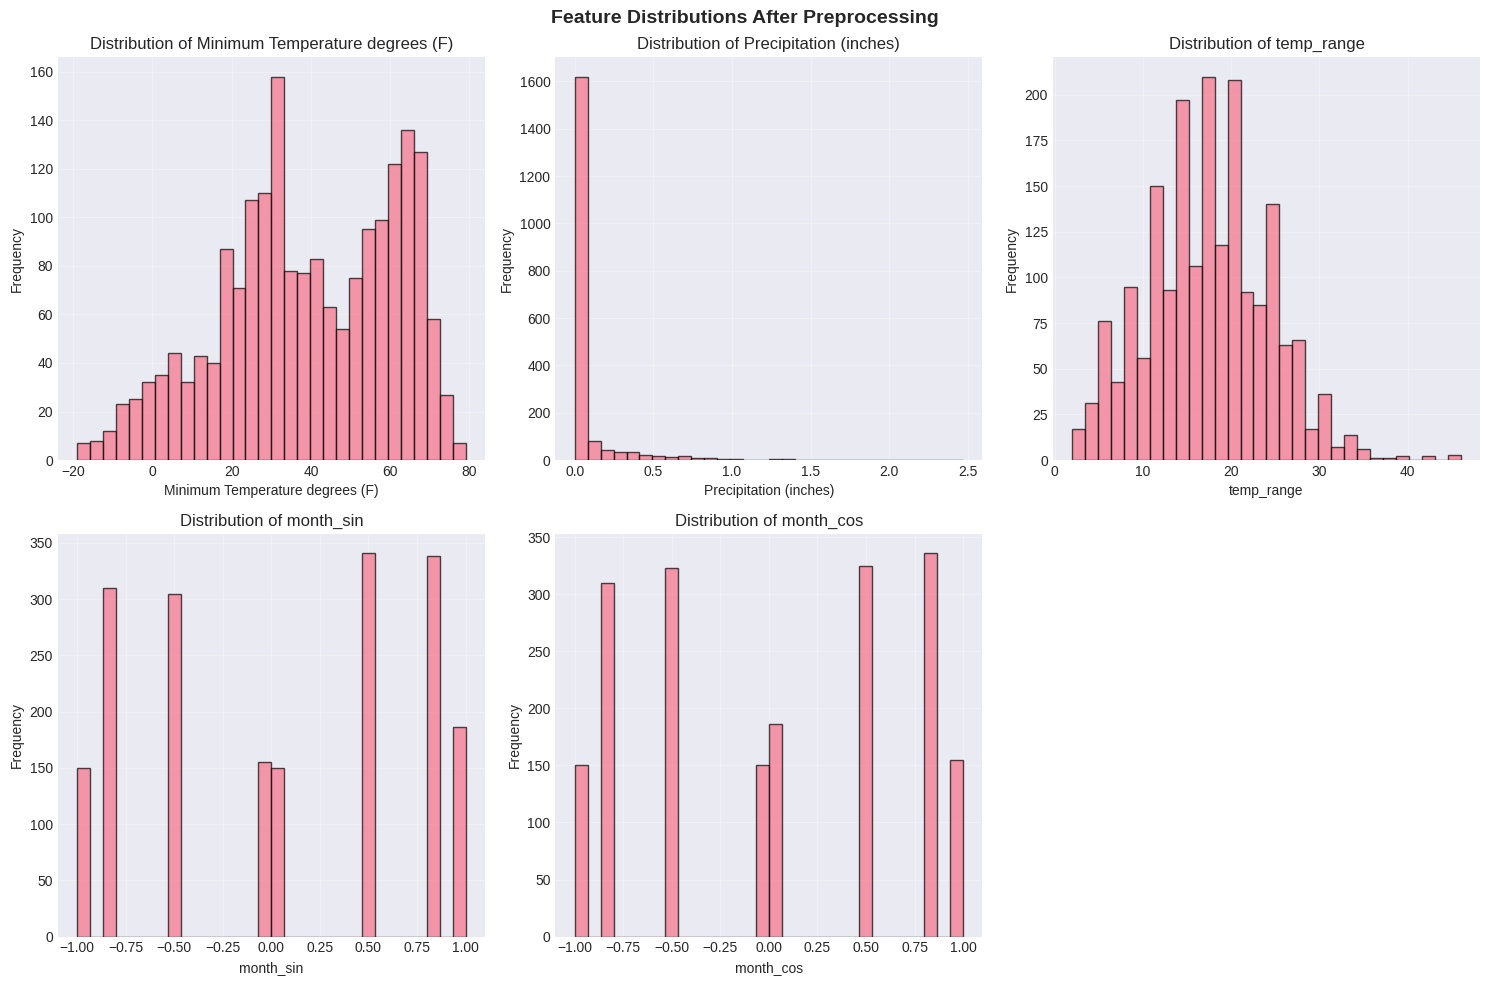

In [ ]:
print("="*60)
print("FEATURE ENGINEERING VISUALIZATION")
print("="*60)

# Figure 12: Feature distributions after preprocessing
feature_cols = ['Minimum Temperature degrees (F)',
                'Precipitation (inches)',
                'temp_range',
                'month_sin',
                'month_cos']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions After Preprocessing', fontsize=14, fontweight='bold')

for idx, feature in enumerate(feature_cols):
    row = idx // 3
    col = idx % 3

    axes[row, col].hist(train_processed[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].grid(True, alpha=0.3)

# Remove empty subplot
if len(feature_cols) < 6:
    axes[1, 2].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

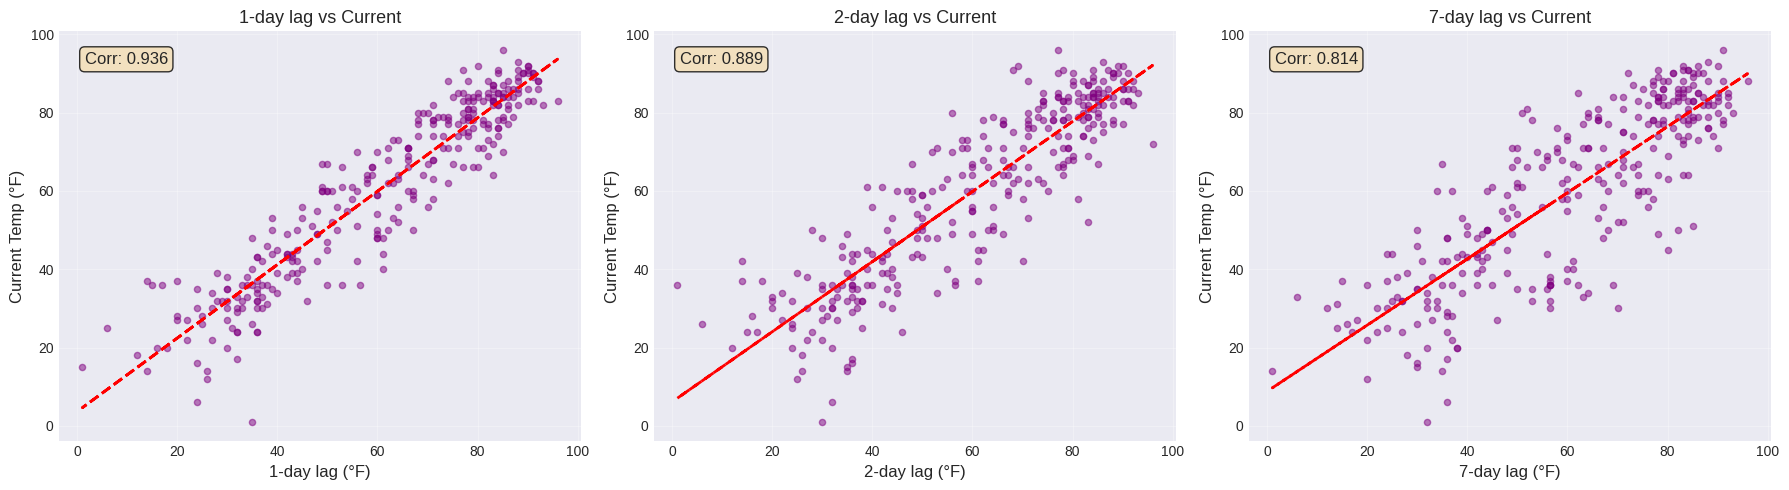

In [ ]:
# Figure 9: Lag Features Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lag_features = [('temp_lag_1', '1-day lag'), ('temp_lag_2', '2-day lag'), ('temp_lag_7', '7-day lag')]

for idx, (lag_feature, title) in enumerate(lag_features):
    axes[idx].scatter(train_df_clean[lag_feature].head(300),
                     train_df_clean['Maximum Temperature degrees (F)'].head(300),
                     alpha=0.5, s=20, color='purple')

    z = np.polyfit(train_df_clean[lag_feature].head(300),
                   train_df_clean['Maximum Temperature degrees (F)'].head(300), 1)
    p = np.poly1d(z)
    axes[idx].plot(train_df_clean[lag_feature].head(300),
                  p(train_df_clean[lag_feature].head(300)),
                  "r--", linewidth=2)

    axes[idx].set_xlabel(f'{title} (°F)', fontsize=12)
    axes[idx].set_ylabel('Current Temp (°F)', fontsize=12)
    axes[idx].set_title(f'{title} vs Current', fontsize=13)
    axes[idx].grid(True, alpha=0.3)

    corr = train_df_clean[lag_feature].corr(train_df_clean['Maximum Temperature degrees (F)'])
    axes[idx].text(0.05, 0.95, f'Corr: {corr:.3f}',
                   transform=axes[idx].transAxes, fontsize=12,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('lag_features.png', dpi=300, bbox_inches='tight')
plt.show()

Prepare Data for Model

In [ ]:
print("="*60)
print("PREPARING DATA FOR MODEL TRAINING")
print("="*60)


print("Cleaning test data...")
test_df_clean = clean_numeric_data(test_df)

# Define features
all_features = [
    'Minimum Temperature degrees (F)',
    'Precipitation (inches)',
    'Snow (inches)',
    'Snow Depth (inches)',
    'temp_range',
    'avg_temp',
    'month_sin', 'month_cos',
    'day_sin', 'day_cos',
    'has_precipitation', 'has_snow',
    'temp_lag_1', 'temp_lag_2', 'temp_lag_7',
    'is_weekend'
]

# Filter existing features
existing_features = [f for f in all_features if f in train_df_clean.columns]
target_col = 'Maximum Temperature degrees (F)'

print(f"Using {len(existing_features)} features for training")
print(f"Features: {existing_features}")

# Prepare training data
X_train = train_df_clean[existing_features].values
y_train = train_df_clean[target_col].values.reshape(-1, 1)

print("\nPreparing test data...")
# Also prepare test data
test_df_clean['Date'] = pd.to_datetime(test_df_clean['Date'])
test_df_clean['month'] = test_df_clean['Date'].dt.month
test_df_clean['day_of_year'] = test_df_clean['Date'].dt.dayofyear
test_df_clean['day_of_week'] = test_df_clean['Date'].dt.dayofweek
test_df_clean['is_weekend'] = test_df_clean['day_of_week'].isin([5, 6]).astype(int)
test_df_clean['temp_range'] = test_df_clean['Maximum Temperature degrees (F)'] - test_df_clean['Minimum Temperature degrees (F)']


test_df_clean['month_sin'] = np.sin(2 * np.pi * test_df_clean['month'] / 12)
test_df_clean['month_cos'] = np.cos(2 * np.pi * test_df_clean['month'] / 12)
test_df_clean['day_sin'] = np.sin(2 * np.pi * test_df_clean['day_of_year'] / 365.25)
test_df_clean['day_cos'] = np.cos(2 * np.pi * test_df_clean['day_of_year'] / 365.25)
test_df_clean['avg_temp'] = (test_df_clean['Maximum Temperature degrees (F)'] + test_df_clean['Minimum Temperature degrees (F)']) / 2
test_df_clean['has_precipitation'] = (test_df_clean['Precipitation (inches)'] > 0).astype(int)
test_df_clean['has_snow'] = (test_df_clean['Snow (inches)'] > 0).astype(int)


train_mean_temp = train_df_clean['Maximum Temperature degrees (F)'].mean()
for lag in [1, 2, 7]:
    test_df_clean[f'temp_lag_{lag}'] = train_mean_temp

# Fill any missing engineered features in test data
for feature in existing_features:
    if feature not in test_df_clean.columns:
        print(f"Warning: {feature} not in test data, filling with 0")
        test_df_clean[feature] = 0

for col in existing_features:
    if col in test_df_clean.columns:
        test_df_clean[col] = pd.to_numeric(test_df_clean[col], errors='coerce')
        test_df_clean[col] = test_df_clean[col].fillna(0)

X_test = test_df_clean[existing_features].values
y_test = test_df_clean[target_col].values.reshape(-1, 1)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Check for NaN values
print(f"\nChecking for NaN values:")
print(f"NaN in X_train: {np.isnan(X_train).sum()}")
print(f"NaN in y_train: {np.isnan(y_train).sum()}")
print(f"NaN in X_test: {np.isnan(X_test).sum()}")
print(f"NaN in y_test: {np.isnan(y_test).sum()}")



PREPARING DATA FOR MODEL TRAINING
Cleaning test data...
Using 16 features for training
Features: ['Minimum Temperature degrees (F)', 'Precipitation (inches)', 'Snow (inches)', 'Snow Depth (inches)', 'temp_range', 'avg_temp', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'has_precipitation', 'has_snow', 'temp_lag_1', 'temp_lag_2', 'temp_lag_7', 'is_weekend']

Preparing test data...

X_train shape: (1935, 16)
y_train shape: (1935, 1)
X_test shape: (154, 16)
y_test shape: (154, 1)

Checking for NaN values:
NaN in X_train: 0
NaN in y_train: 0
NaN in X_test: 0
NaN in y_test: 0


In [ ]:
# BLOCK 11: Scale Data and Create Sequences
# ============================================================================

print("\n" + "="*60)
print("SCALING DATA AND CREATING SEQUENCES")
print("="*60)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print(f"Scaling completed successfully")

# Check scaled data
print(f"\nScaled data statistics:")
print(f"X_train_scaled - Min: {X_train_scaled.min():.2f}, Max: {X_train_scaled.max():.2f}")
print(f"X_train_scaled - Mean: {X_train_scaled.mean():.2f}, Std: {X_train_scaled.std():.2f}")
print(f"y_train_scaled - Min: {y_train_scaled.min():.2f}, Max: {y_train_scaled.max():.2f}")

# Create sequences function
def create_sequences(X, y, sequence_length=14):
    X_seq, y_seq = [], []

    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length])

    return np.array(X_seq), np.array(y_seq)

# Create sequences
sequence_length = 14
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, sequence_length)

print(f"\nSequences created:")
print(f"Training sequences: {X_train_seq.shape}")
print(f"Training labels: {y_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")
print(f"Test labels: {y_test_seq.shape}")

# Check if we have enough data
if len(X_train_seq) == 0:
    print("ERROR: No training sequences created!")
    print("This might be because sequence_length is too large for the data.")
    print(f"Try reducing sequence_length from {sequence_length} to a smaller value.")
elif len(X_test_seq) == 0:
    print("WARNING: No test sequences created!")
    print("Test set might be too small for the sequence length.")
else:
    print("\nData preparation completed successfully!")


SCALING DATA AND CREATING SEQUENCES
Scaling completed successfully

Scaled data statistics:
X_train_scaled - Min: -2.65, Max: 14.01
X_train_scaled - Mean: 0.00, Std: 1.00
y_train_scaled - Min: -2.62, Max: 1.87

Sequences created:
Training sequences: (1921, 14, 16)
Training labels: (1921, 1)
Test sequences: (140, 14, 16)
Test labels: (140, 1)

Data preparation completed successfully!


In [ ]:
print("\n" + "="*60)
print("SCALING DATA AND CREATING SEQUENCES")
print("="*60)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print(f"Scaling completed successfully")

# Create sequences function
def create_sequences(X, y, sequence_length=14):
    X_seq, y_seq = [], []

    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length])

    return np.array(X_seq), np.array(y_seq)

# Create sequences
sequence_length = 14
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, sequence_length)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Training labels: {y_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")
print(f"Test labels: {y_test_seq.shape}")


SCALING DATA AND CREATING SEQUENCES
Scaling completed successfully
Training sequences: (1921, 14, 16)
Training labels: (1921, 1)
Test sequences: (140, 14, 16)
Test labels: (140, 1)


In [ ]:
print("="*60)
print("BUILDING AND TRAINING LSTM MODEL")
print("="*60)

# Build model
input_shape = (sequence_length, X_train_scaled.shape[1])

model = Sequential([
    LSTM(64, input_shape=input_shape, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

model.summary()

# Train model
print("\nTraining model...")
callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

# Split for validation
split_idx = int(len(X_train_seq) * 0.8)
X_train_final = X_train_seq[:split_idx]
y_train_final = y_train_seq[:split_idx]
X_val = X_train_seq[split_idx:]
y_val = y_train_seq[split_idx:]

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

BUILDING AND TRAINING LSTM MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 14, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)


Training model...
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.4516 - mae: 0.5298 - val_loss: 0.1665 - val_mae: 0.3223
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1897 - mae: 0.3434 - val_loss: 0.1605 - val_mae: 0.3117
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1624 - mae: 0.3172 - val_loss: 0.1497 - val_mae: 0.3038
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1643 - mae: 0.3188 - val_loss: 0.1480 - val_mae: 0.3033
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1551 - mae: 0.3102 - val_loss: 0.1433 - val_mae: 0.3003
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1484 - mae: 0.3036 - val_loss: 0.1458 - val_mae: 0.2997
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1366 - mae: 0.2903 - val_loss: 0.1555 - val_mae: 0.3035
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1394 - mae: 0.2907 - val_loss: 0.1443 - val_mae: 0.2960
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

Model Evaluation

In [ ]:
# Make predictions
y_pred_scaled = model.predict(X_test_seq, verbose=0)

# Inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_seq)

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("\nModel Performance Metrics:")
print(f"MAE (Mean Absolute Error): {mae:.2f}°F")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}°F")
print(f"R² Score: {r2:.4f}")


Model Performance Metrics:
MAE (Mean Absolute Error): 6.28°F
MSE (Mean Squared Error): 73.89
RMSE (Root Mean Squared Error): 8.60°F
R² Score: 0.1160


Final Visualizations

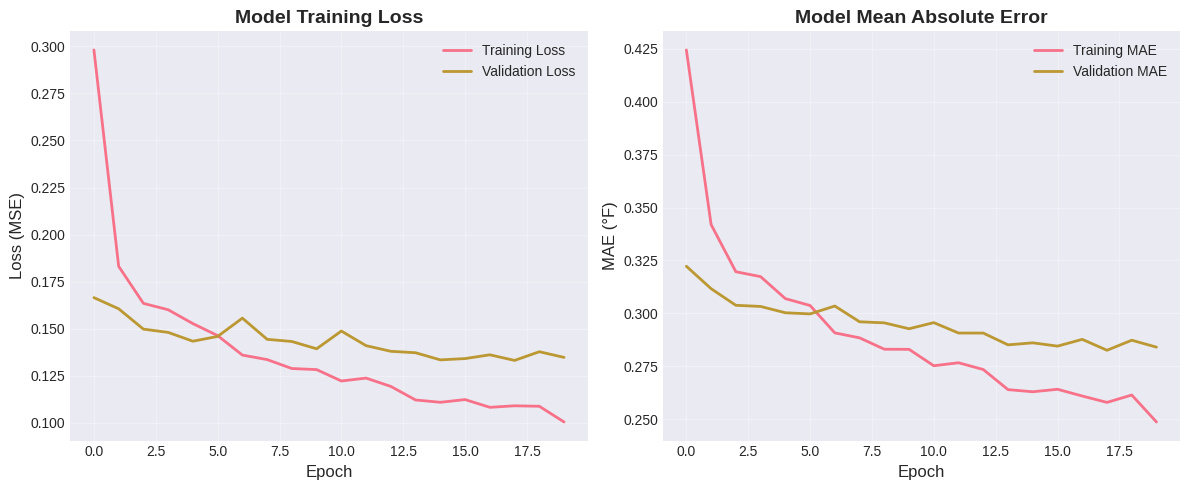

In [ ]:
# Figure 10: Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Model Training Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MAE (°F)', fontsize=12)
plt.title('Model Mean Absolute Error', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()


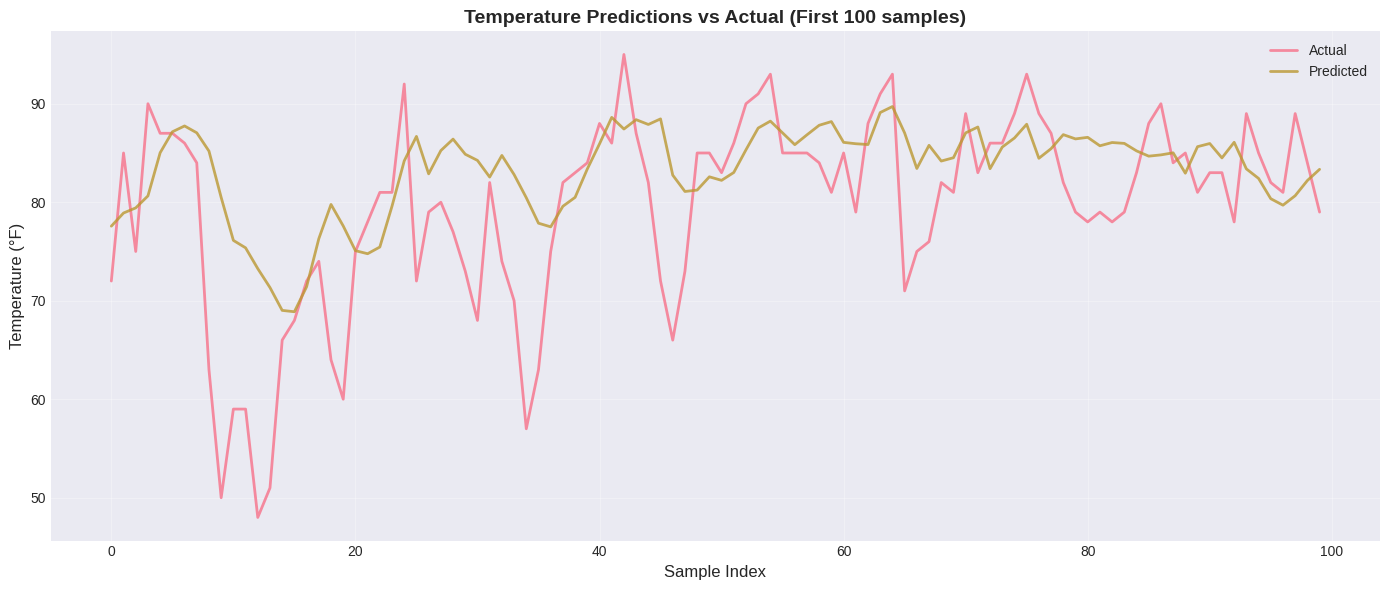

In [ ]:
# Figure 11: Predictions vs Actual
plt.figure(figsize=(14, 6))

plt.plot(y_true[:100], label='Actual', linewidth=2, alpha=0.8)
plt.plot(y_pred[:100], label='Predicted', linewidth=2, alpha=0.8)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Temperature (°F)', fontsize=12)
plt.title('Temperature Predictions vs Actual (First 100 samples)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

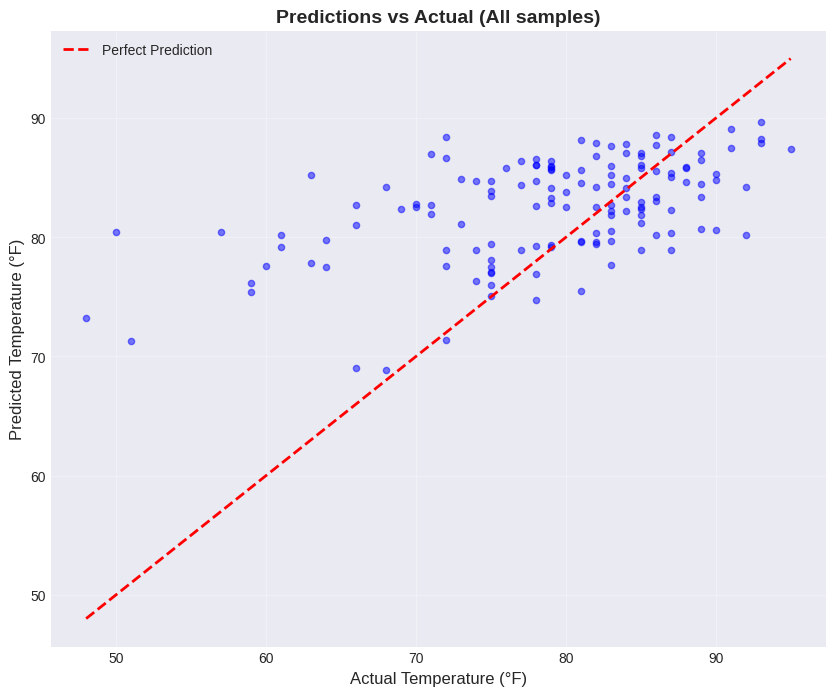

In [ ]:
# Figure 12: Scatter plot of predictions
plt.figure(figsize=(10, 8))
plt.scatter(y_true, y_pred, alpha=0.5, s=20, c='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Temperature (°F)', fontsize=12)
plt.ylabel('Predicted Temperature (°F)', fontsize=12)
plt.title('Predictions vs Actual (All samples)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

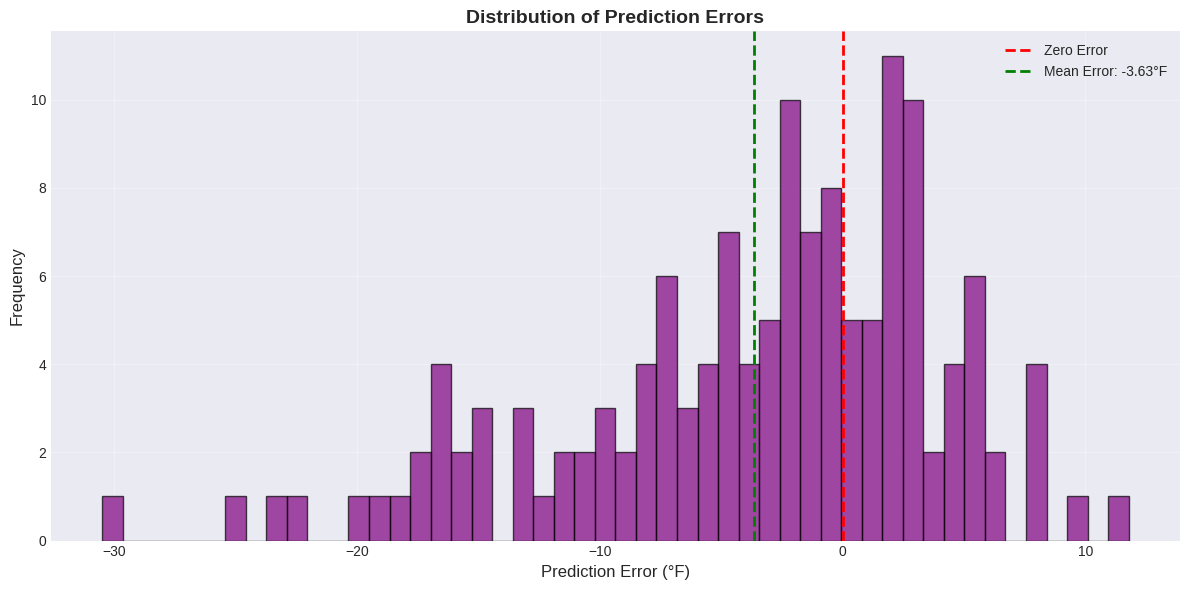

In [ ]:
# Figure 13: Error distribution
errors = y_true - y_pred
plt.figure(figsize=(12, 6))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(x=errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean Error: {errors.mean():.2f}°F')
plt.xlabel('Prediction Error (°F)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

 Save Model and Summary

In [ ]:
# Save model
model.save('temperature_predictor_final.keras')

# Save scalers
import joblib
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
joblib.dump(existing_features, 'feature_columns.pkl')

print("Model and scalers saved successfully!")
print("\nFiles saved:")
print("  - temperature_predictor_final.keras (model)")
print("  - scaler_X.pkl (feature scaler)")
print("  - scaler_y.pkl (target scaler)")
print("  - feature_columns.pkl (feature names)")

# Create summary report
summary = {
    'model_type': 'LSTM',
    'sequence_length': sequence_length,
    'num_features': len(existing_features),
    'training_samples': len(X_train_seq),
    'test_samples': len(X_test_seq),
    'performance_metrics': {
        'MAE': float(mae),
        'MSE': float(mse),
        'RMSE': float(rmse),
        'R2': float(r2)
    },
    'features_used': existing_features
}

import json
with open('model_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\nModel summary saved to 'model_summary.json'")

Model and scalers saved successfully!

Files saved:
  - temperature_predictor_final.keras (model)
  - scaler_X.pkl (feature scaler)
  - scaler_y.pkl (target scaler)
  - feature_columns.pkl (feature names)

Model summary saved to 'model_summary.json'


In [ ]:
import pandas as pd

data = {
    "ID": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Minimum Temperature degrees (F)": [70, 73, 60, 74, 57, 71, 56, 57, 51, 60, 74]
}

df = pd.DataFrame(data)
df.to_csv("submission.csv", index=False)